# Corrected record: every paper number checked

This notebook is a runnable demo of **`eval.py`**, the evaluation from iteration 5 (evaluation 4) of an NL→FOL
*gold-free faithfulness metrics* project. The script uses no LLM calls, runs on CPU only and costs $0. It audits the numbers
in the iteration-4 paper draft. For every hand-curated claim (a literal such as `0.614 [0.493, 0.736]` quoted in the
hypothesis or in the review), it:

1. pulls the value from the **source result file** that the claim cites, using a locator (JSON key path, CSV cell, or regex);
2. compares the claim literal to the file value with a **precision rule**: MATCH iff |claim − file| ≤ ½·10⁻ᵈ, where d is
   the number of decimals written in the claim. A CI matches only if both bounds match, and signs must agree;
3. finds the same number in the **paper draft** and checks the paper's version against the file.

It then maps every decimal number named in the 11 reviewer critiques to a `numbers.csv` row (`review_numbers`).

**What the full run found:** all 244 claims MATCH their source files. The paper draft misquotes 15 of them. For example,
all six §4.2 CIs in the paper are narrower than the CIs in the source files (c_csc paper `[0.545, 0.679]` vs file `[0.493, 0.736]`),
and the G2 gate is reported as `FAIL` although the file says `NOT_READ`.

**Demo scope.** The original script reads about 60 result files at absolute server paths plus the paper draft. Those files
are not available here, so `mini_demo_data.json` holds the output of that one step, the **locator step**, for 100 of the
244 claims:

- the claim literal;
- the raw value the locator pulled from the file (`source_value_raw`, `source_ci_raw`);
- the value quoted in the paper (`paper_value`).

Everything after that step runs here unchanged: the precision rule, the per-claim MATCH/MISMATCH decision, `numbers.csv`
and `mismatches.csv`, the mapping of review numbers, and the status counts.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

## Imports
The original `eval.py` import block, followed by what the demo adds: `math` and `typing.Any`, which the checker module
uses, plus pandas and matplotlib for the results cell. The original also imported its `src.*` modules. The checker
functions those modules provided are copied into the cells below.

In [2]:
from __future__ import annotations

import csv
import json
import re
import subprocess
import sys
import time
from collections import Counter
from pathlib import Path

from loguru import logger

# --- used by the copied checker functions (src/checker.py) ---
import math
from types import SimpleNamespace
from typing import Any

# --- notebook additions for the results cell ---
import pandas as pd
import matplotlib.pyplot as plt

WS = Path.cwd()  # original: Path(__file__).resolve().parent
(WS / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(WS / "logs/run.log", rotation="30 MB", level="DEBUG")

2

## Data loading
The loader tries the GitHub copy of `mini_demo_data.json` first and falls back to a local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-5/evaluation-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{len(data['claims'])} claims in the demo subset; {len(data['review']['critiques'])} review critiques")
print("example claim:", json.dumps(data["claims"][0], indent=1, ensure_ascii=False)[:900])

Subset (100 of 244) of the hand-curated claims checked by the corrected-record evaluation: each claim literal from the hypothesis/review, the value the original locator pulled from its source file, and the value quoted in the iter-4 paper draft; plus the 11 review critiques and the full-run aggregate metrics for comparison.
100 claims in the demo subset; 11 review critiques
example claim: {
 "id": "x9_csc",
 "has_paper_pattern": true,
 "sec": "hyp §0.3A T4",
 "text": "c_csc strat AUROC",
 "value": "0.614",
 "ci": "[0.493, 0.736]",
 "role": "DEV",
 "source_path": "iter_4/gen_art/gen_art_experiment_9/results/analysis.json",
 "locator": "iter_4/gen_art/gen_art_experiment_9/results/analysis.json :: b_PRIMARY.metrics.R_AB [strat].c_csc.point || CI: iter_4/gen_art/gen_art_experiment_9/results/analysis.json :: b_PRIMARY.metrics.R_AB [strat].c_csc.ci",
 "source_value_raw": 0.613643899204244,
 "source_ci_raw": [
  0.493245253164557,
  0.7358218618436089
 ],
 "paper_value": "[0.545, 0.679]",
 "p

## Config
- `N_CLAIMS` sets how many claims from the demo subset are checked: at most 100 here, 244 in the original full run.
- `N_CRITIQUES` sets how many of the 11 review critiques are scanned for numbers.

The whole notebook takes a few seconds, so both are set to the full subset.

In [5]:
N_CLAIMS = 100      # claims to check (min 1; demo subset has 100; original full run: 244 claims + 258 transcriptions)
N_CRITIQUES = 11    # review critiques scanned by review_numbers (original: all 11)

## Precision rule (copied from `src/checker.py`)
- `parse_literal` turns a literal such as `44.9%`, `+0.099`, `$4.33` or `1.2e-3` into a value and a tolerance
  of ½·10⁻ᵈ. The tolerance comes from how many decimals the author wrote. Percentages are compared as fractions.
- `num_match` applies that tolerance and also rejects sign disagreements.
- `fmt_like` formats a file value at the claim's precision and style, for display only.

In [6]:
NUM_RE = r"[+\-−]?\$?\d[\d,]*(?:\.\d+)?(?:e[+\-−]?\d+)?%?"


def norm(s: str) -> str:
    return s.replace("−", "-").replace("−", "-").strip()


def is_numeric_literal(s: str) -> bool:
    return bool(re.fullmatch(r"[+\-]?\$?\d[\d,]*(?:\.\d+)?(?:e[+\-]?\d+)?%?", norm(s)))


def parse_literal(s: str) -> tuple[float, float, dict]:
    """Return (value_as_fraction_or_number, tolerance, format_info)."""
    t = norm(s)
    info = {"sign": t.startswith("+"), "pct": t.endswith("%"), "usd": "$" in t, "sci": "e" in t.lower()}
    core = t.replace("$", "").replace(",", "").rstrip("%").lstrip("+")
    if info["sci"]:
        mant, exp = core.lower().split("e")
        dec = len(mant.split(".")[1]) if "." in mant else 0
        val = float(core)
        tol = 0.5 * 10 ** (-dec) * 10 ** int(exp)
        info["dec"], info["exp"] = dec, int(exp)
    else:
        dec = len(core.split(".")[1]) if "." in core else 0
        val = float(core)
        tol = 0.5 * 10 ** (-dec)
        info["dec"] = dec
    if info["pct"]:
        val /= 100.0
        tol /= 100.0
    info["thousands"] = "," in t
    return val, tol * (1 + 1e-9) + 1e-12, info


def parse_ci(s: str) -> list[str]:
    parts = [p.strip() for p in norm(s).strip("[]").split(",")]
    if len(parts) != 2:
        raise ValueError(f"bad CI literal {s}")
    return parts


def fmt_like(v: float, claim_literal: str) -> str:
    """Format a file value at the claim literal's precision/style (display only)."""
    _, _, info = parse_literal(claim_literal)
    x = v * 100.0 if info["pct"] else v
    if info.get("sci"):
        body = f"{x / 10 ** info['exp']:.{info['dec']}f}e{info['exp']}"
    elif info["thousands"]:
        body = f"{x:,.{info['dec']}f}"
    else:
        body = f"{x:.{info['dec']}f}"
    if body.startswith("-"):
        body = "−" + body[1:]
    elif info["sign"] and x > 0:
        body = "+" + body
    if info["usd"]:
        body = ("−$" + body[1:]) if body.startswith("−") else "$" + body
    return body + ("%" if info["pct"] else "")


def fmt_ci_like(ci: list[float], claim_ci: str) -> str:
    lo_l, hi_l = parse_ci(claim_ci)
    return f"[{fmt_like(ci[0], lo_l)}, {fmt_like(ci[1], hi_l)}]"


def num_match(claim_literal: str, source: float) -> bool:
    val, tol, _ = parse_literal(claim_literal)
    if val != 0 and source != 0 and math.copysign(1, val) != math.copysign(1, source) and abs(source) > tol:
        return False
    return abs(val - source) <= tol


# eval.py calls these as CK.<fn>; keep that spelling so eval.py's code below is unchanged
CK = SimpleNamespace(parse_literal=parse_literal, parse_ci=parse_ci, num_match=num_match)

# quick illustration of the rule
for lit, src in [("0.614", 0.613643899204244), ("0.61", 0.6189), ("44.9%", 0.4488), ("+0.099", -0.099)]:
    v, tol, _ = parse_literal(lit)
    print(f"claim {lit:>7} vs file {src:<18} tol={tol:.5f} -> {'MATCH' if num_match(lit, src) else 'MISMATCH'}")

claim   0.614 vs file 0.613643899204244  tol=0.00050 -> MATCH
claim    0.61 vs file 0.6189             tol=0.00500 -> MISMATCH
claim   44.9% vs file 0.4488             tol=0.00050 -> MATCH
claim  +0.099 vs file -0.099             tol=0.00050 -> MISMATCH


## Checking one claim (`check_claim` from `src/checker.py`)
This is the original comparison logic, with two changes:

- **File side.** The original calls `L.resolve(cl["loc"])` to open the source file. Here the raw value that call
  returned is read from the data (`source_value_raw`, `source_ci_raw`).
- **Paper side.** Some claims have a dedicated paper regex (`pp`). For those, the value the regex extracted is
  compared to the file independently, and this is how the 15 paper misquotes are found. Every other claim was
  located in the paper by grepping its own literal, so its paper status equals its file status.

Unchanged: the precision rule, the CI rule (both bounds must match) and exact string equality for verdict labels.

In [7]:
def check_claim(cl: dict) -> dict:
    row = {k: cl.get(k) for k in ("id", "sec", "text", "value", "ci", "role")}
    row.update(source_path="", locator="", source_value="", source_ci="", match_hyp_vs_file="", paper_value="",
               paper_line="", match_paper_vs_file="", note="", source_value_raw=None, source_ci_raw=None)
    # original: v, s = L.resolve(cl["loc"]) -- the locator step, pre-computed in mini_demo_data.json
    v, s = cl["source_value_raw"], cl["locator"]
    row["locator"] = s
    row["source_path"] = cl["source_path"]
    ci_src = cl["source_ci_raw"]
    if is_numeric_literal(cl["value"]):
        fv = float(v)
        row["source_value_raw"] = fv
        row["source_value"] = fmt_like(fv, cl["value"])
        ok = num_match(cl["value"], fv)
    else:
        row["source_value"] = str(v)
        row["source_value_raw"] = str(v)
        ok = str(v) == cl["value"]
    if cl.get("ci"):
        if ci_src is None:
            row["note"] += " CI not in source;"
        if ci_src is not None:
            row["source_ci_raw"] = ci_src
            row["source_ci"] = fmt_ci_like(ci_src, cl["ci"])
            lo_l, hi_l = parse_ci(cl["ci"])
            ok = ok and num_match(lo_l, ci_src[0]) and num_match(hi_l, ci_src[1])
    elif ci_src is not None:
        row["source_ci_raw"] = ci_src
        row["source_ci"] = f"[{ci_src[0]:.3f}, {ci_src[1]:.3f}]".replace("-", "−")
    row["match_hyp_vs_file"] = "MATCH" if ok else "MISMATCH"
    # paper side
    pv, line = cl["paper_value"], cl["paper_line"]
    if cl["has_paper_pattern"]:  # original: pv, line = paper_pattern(cl["pp"], cl.get("ps"))
        if not pv:
            row["paper_value"], row["match_paper_vs_file"] = "", "NOT_IN_PAPER"
        else:
            row["paper_value"], row["paper_line"] = pv, line
            if pv.startswith("["):
                lo_l, hi_l = parse_ci(pv)
                okp = row["source_ci_raw"] is not None and num_match(lo_l, row["source_ci_raw"][0]) and num_match(hi_l, row["source_ci_raw"][1])
            elif is_numeric_literal(pv) and isinstance(row["source_value_raw"], float):
                okp = num_match(pv, row["source_value_raw"])
            else:
                okp = pv == str(row["source_value_raw"])
            row["match_paper_vs_file"] = "MATCH" if okp else "MISMATCH"
    else:  # original: var, line = grep_paper(cl["value"], cl.get("ps"))
        if not pv:
            row["match_paper_vs_file"] = "NOT_IN_PAPER"
        else:
            row["paper_value"], row["paper_line"] = pv, line
            row["match_paper_vs_file"] = row["match_hyp_vs_file"]
    return row


def check_all(claims: list[dict]) -> list[dict]:
    return [check_claim(c) for c in claims]

## Run the checker (the first part of `main()`)
The next cell checks every claim in the subset and logs the status counts. It then confirms that each recomputed status
equals the status the original full run wrote, which shows the replay reproduces the original decisions.

In [8]:
t0 = time.time()
CLAIMS = data["claims"][:N_CLAIMS]
logger.info(f"checking {len(CLAIMS)} claims")
rows = check_all(CLAIMS)
cnt = Counter(r["match_hyp_vs_file"] for r in rows)
logger.info(f"hyp-vs-file: {dict(cnt)}; paper-vs-file: {dict(Counter(r['match_paper_vs_file'] for r in rows))}")
bad = [r for r in rows if r["match_hyp_vs_file"] in ("NOT_FOUND", "AMBIGUOUS")]
for r in bad:
    logger.warning(f"{r['id']}: {r['match_hyp_vs_file']} {r['note'][:160]}")

# demo-only check: recomputed statuses == statuses written by the original full run
agree = sum(r["match_hyp_vs_file"] == c["orig_match_hyp_vs_file"] and r["match_paper_vs_file"] == c["orig_match_paper_vs_file"]
            for r, c in zip(rows, CLAIMS))
logger.info(f"recomputed statuses agree with the original run on {agree}/{len(rows)} claims")

16:52:27|INFO   |checking 100 claims


16:52:27|INFO   |hyp-vs-file: {'MATCH': 100}; paper-vs-file: {'MISMATCH': 15, 'MATCH': 50, 'NOT_IN_PAPER': 35}


16:52:27|INFO   |recomputed statuses agree with the original run on 100/100 claims


## `numbers.csv` and `mismatches.csv` (`write_numbers` from `eval.py`)
Each checked claim becomes one CSV row. `mismatches.csv` holds every row where the hypothesis disagrees with its file
or the paper disagrees with the file.

In [9]:
NUM_COLS = ["claim_id", "section", "claim_text", "claim_value", "claim_ci", "source_path", "locator", "source_value",
            "source_ci", "match_hyp_vs_file", "paper_value", "paper_line", "match_paper_vs_file", "data_role", "note"]


def write_numbers(rows: list[dict], path: Path) -> None:
    with path.open("w", newline="") as f:
        f.write("# source: every row's value is read by src/io_locators.py from source_path at locator (never typed); "
                "claim_value is the hypothesis/review literal; statuses per src/checker.py precision rule\n")
        w = csv.writer(f)
        w.writerow(NUM_COLS)
        for r in rows:
            w.writerow([r["id"], r.get("sec"), r.get("text"), r.get("value") or "", r.get("ci") or "", r.get("source_path"),
                        r.get("locator"), r.get("source_value"), r.get("source_ci"), r.get("match_hyp_vs_file"),
                        r.get("paper_value"), r.get("paper_line"), r.get("match_paper_vs_file"), r.get("role"), r.get("note")])


write_numbers(rows, WS / "numbers.csv")
mism = [r for r in rows if r.get("match_hyp_vs_file") in ("MISMATCH", "NOT_FOUND", "AMBIGUOUS") or r.get("match_paper_vs_file") == "MISMATCH"]
write_numbers(mism, WS / "mismatches.csv")
logger.info(f"numbers.csv: {len(rows)} rows; mismatches.csv: {len(mism)} rows")

16:52:27|INFO   |numbers.csv: 100 rows; mismatches.csv: 15 rows


## Mapping review numbers (`review_numbers` from `eval.py`)
Every decimal or percentage named in the reviewer's critiques must be covered by some `numbers.csv` row, meaning a claim
value, a CI bound or a paper value within the literal's precision. Otherwise it is reported as `UNMAPPED`.

The function is unchanged except that `rv` is read from the loaded data instead of from the review file. The full run
checked 244 claims plus 258 transcribed cells and mapped 205 of the 207 critique numbers (2 `UNMAPPED`). This demo
holds only 100 claims, so roughly 60 numbers come out `UNMAPPED` here that the full run maps.

In [10]:
def review_numbers(rows: list[dict]) -> list[dict]:
    """(ii) every number named in the 11 critiques -> covered by a numbers.csv row or UNMAPPED."""
    rv = {"critiques": data["review"]["critiques"][:N_CRITIQUES]}  # original: json.loads(L._read_text(L.REVIEW))
    vals = []
    for r in rows:
        for key in ("source_value_raw",):
            v = r.get(key)
            if isinstance(v, float):
                vals.append((v, r["id"]))
        ci = r.get("source_ci_raw")
        if ci:
            vals += [(ci[0], r["id"]), (ci[1], r["id"])]
        pv = r.get("paper_value")
        if pv and str(pv).startswith("["):
            try:
                for b in CK.parse_ci(str(pv)):
                    vals.append((CK.parse_literal(b)[0], r["id"] + "(paper CI)"))
            except ValueError:
                pass
        if pv and re.fullmatch(r"[+\-−]?\$?\d[\d.,]*%?", str(pv)):
            try:
                vals.append((CK.parse_literal(str(pv))[0], r["id"] + "(paper)"))
            except ValueError:
                pass
    out = []
    for k, cr in enumerate(rv["critiques"], 1):
        text = cr["description"] + " " + cr["suggested_action"]
        for m in re.finditer(r"(?<![\w.])[+\-−]?\$?\d+(?:\.\d+)?%?(?![\w])", text):
            lit = m.group(0)
            pre = text[max(0, m.start() - 8): m.start()]
            if re.search(r"(§|§\d(?:\.\d)?[–-]|arXiv |\()$", pre) or re.fullmatch(r"\d{4}\.\d{5}", lit):
                continue  # section numbers and arXiv ids are not measurements
            if not re.search(r"\.\d|%", lit):
                continue  # integers (section numbers, counts) are not checked here
            try:
                val, tol, _ = CK.parse_literal(lit)
            except ValueError:
                continue
            hits = sorted({rid for v, rid in vals if abs(abs(v) - abs(val)) <= tol})
            out.append(dict(critique=k, literal=lit, context=text[max(0, m.start() - 50): m.end() + 30].replace("\n", " "),
                            covered_by=";".join(hits[:5]), status="MAPPED" if hits else "UNMAPPED"))
    return out


rn = review_numbers(rows)
(WS / "tables").mkdir(exist_ok=True)
with (WS / "tables/review_numbers.csv").open("w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["critique", "literal", "status", "covered_by", "context"])
    w.writeheader()
    for r in rn:
        w.writerow(r)
logger.info(f"review critique numbers: {Counter(r['status'] for r in rn)}")
logger.info(f"done in {time.time() - t0:.2f}s")

16:52:27|INFO   |review critique numbers: Counter({'MAPPED': 145, 'UNMAPPED': 62})


16:52:27|INFO   |done in 0.09s


## Results
Three views of the output:

- the paper-vs-file misquotes found in this subset;
- status counts for the subset next to the counts from the original full run;
- a plot of each misquoted CI, showing the paper's interval against the source file's interval.

=== Paper-vs-file MISMATCHES (paper quotes a number that differs from its source file) ===
                       id                                                                            text      paper_value       file_value paper_line
                   x9_csc                                                               c_csc strat AUROC   [0.545, 0.679]   [0.493, 0.736]       1063
                x9_fexact                                        FREE_exact (same 3 families) strat AUROC   [0.704, 0.827]   [0.686, 0.844]       1060
                x9_calign                                            c_score_align strat AUROC on PRIMARY   [0.711, 0.827]   [0.682, 0.857]       1059
                   x9_ppt                                              p_peer_text strat AUROC on PRIMARY   [0.742, 0.848]   [0.700, 0.880]       1058
                    x9_s4                                                  S4_full strat AUROC on PRIMARY   [0.672, 0.791]   [0.635, 0.826]       1061
   

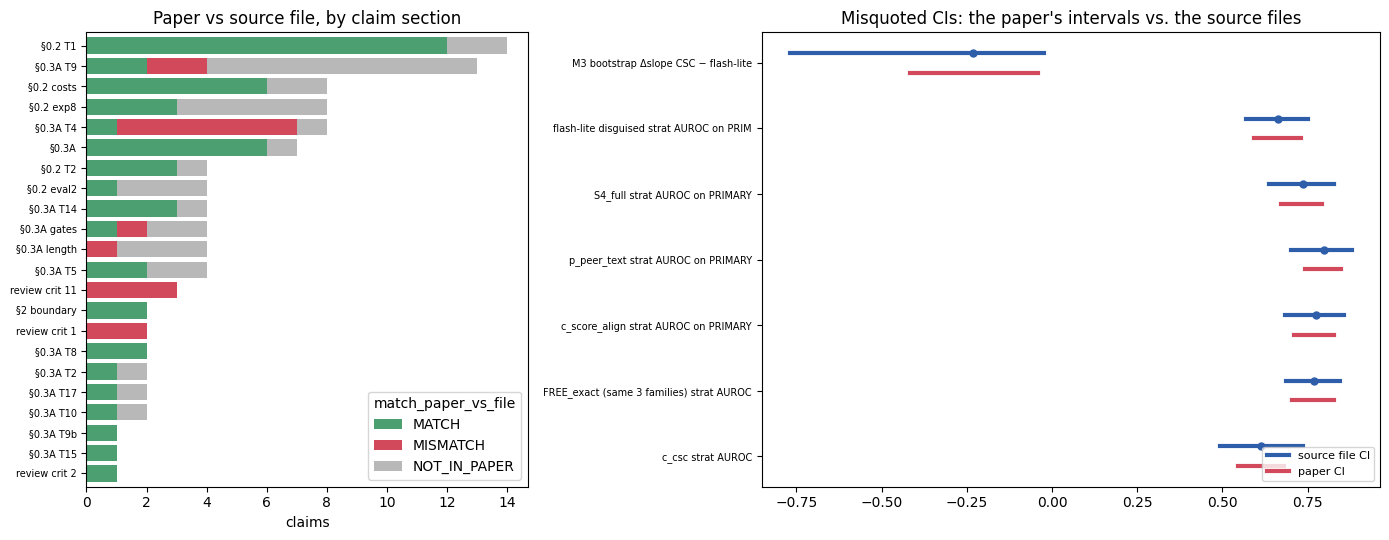

In [11]:
pd.set_option("display.width", 200, "display.max_colwidth", 60)
df = pd.DataFrame(rows)

print("=== Paper-vs-file MISMATCHES (paper quotes a number that differs from its source file) ===")
mm = df[df.match_paper_vs_file == "MISMATCH"]
print(mm.assign(file_value=[r.source_ci if str(r.paper_value).startswith("[") else r.source_value for r in mm.itertuples()])
        [["id", "text", "paper_value", "file_value", "paper_line"]].to_string(index=False))

print("\n=== Status counts: this demo subset vs the original full run ===")
full = data["full_run_counts"]
summary = pd.DataFrame({
    "demo (hyp vs file)": pd.Series(Counter(df.match_hyp_vs_file)),
    "full (hyp vs file)": pd.Series(full["match_hyp_vs_file"]),
    "demo (paper vs file)": pd.Series(Counter(df.match_paper_vs_file)),
    "full (paper vs file)": pd.Series(full["match_paper_vs_file"]),
}).fillna(0).astype(int)
print(summary.to_string())
print(f"\nfull run: {full['n_claims']} claims; review numbers in demo: {dict(Counter(r['status'] for r in rn))}")
ma = data["full_run_metrics_agg"]
print(f"full run also: lint failures {ma['lint_failures']:.0f}, independent audit {ma['audit_rederive_pass']:.0f}/{ma['audit_rederive_checks']:.0f} pass, "
      f"checker mutations caught {ma['checker_mutation_caught']:.0f}/10, LLM calls {ma['llm_calls']:.0f}")

# --- plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1, 1.4]})
ax = axes[0]
ct = pd.crosstab(df.sec.str.replace("hyp ", "").str.replace(r"\s*\[.*\]", "", regex=True), df.match_paper_vs_file)
ct = ct.loc[ct.sum(axis=1).sort_values().index]
colors = {"MATCH": "#4C9F70", "MISMATCH": "#D1495B", "NOT_IN_PAPER": "#B8B8B8"}
ct.plot.barh(stacked=True, ax=ax, color=[colors[c] for c in ct.columns], width=0.8)
ax.set_title("Paper vs source file, by claim section")
ax.set_xlabel("claims"); ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=7)

ax = axes[1]
ci_rows = [r for r in rows if r["match_paper_vs_file"] == "MISMATCH" and str(r["paper_value"]).startswith("[") and r["source_ci_raw"]]
for i, r in enumerate(ci_rows):
    plo, phi = [parse_literal(b)[0] for b in parse_ci(r["paper_value"])]
    flo, fhi = r["source_ci_raw"]
    ax.plot([flo, fhi], [i + 0.15] * 2, color="#2E5EAA", lw=3, label="source file CI" if i == 0 else None)
    ax.plot([plo, phi], [i - 0.15] * 2, color="#D1495B", lw=3, label="paper CI" if i == 0 else None)
    if isinstance(r["source_value_raw"], float):
        ax.plot(r["source_value_raw"], i + 0.15, "o", color="#2E5EAA", ms=5)
ax.set_yticks(range(len(ci_rows)), [r["text"][:40] for r in ci_rows], fontsize=7)
ax.set_title("Misquoted CIs: the paper's intervals vs. the source files")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()